In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
df = pd.read_csv(r"C:\Users\Pratyasha\Downloads\new.csv")
df.info

<bound method DataFrame.info of          ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
0      5524        1957  Graduation         Single  58138.0        0   
1      2174        1954  Graduation         Single  46344.0        1   
2      4141        1965  Graduation       Together  71613.0        0   
3      6182        1984  Graduation       Together  26646.0        1   
4      5324        1981         PhD        Married  58293.0        1   
...     ...         ...         ...            ...      ...      ...   
2235  10870        1967  Graduation        Married  61223.0        0   
2236   4001        1946         PhD       Together  64014.0        2   
2237   7270        1981  Graduation       Divorced  56981.0        0   
2238   8235        1956      Master       Together  69245.0        0   
2239   9405        1954         PhD        Married  52869.0        1   

      Teenhome Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  \
0            0  04-09-2012    

In [189]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [190]:
(df == 0).sum()

ID                        1
Year_Birth                0
Education                 0
Marital_Status            0
Income                    0
Kidhome                1293
Teenhome               1158
Dt_Customer               0
Recency                  28
MntWines                 13
MntFruits               400
MntMeatProducts           1
MntFishProducts         384
MntSweetProducts        419
MntGoldProds             61
NumDealsPurchases        46
NumWebPurchases          49
NumCatalogPurchases     586
NumStorePurchases        15
NumWebVisitsMonth        11
AcceptedCmp3           2077
AcceptedCmp4           2073
AcceptedCmp5           2077
AcceptedCmp1           2096
AcceptedCmp2           2210
Complain               2219
Z_CostContact             0
Z_Revenue                 0
Response               1906
dtype: int64

In [191]:
df.drop([
    'AcceptedCmp1','AcceptedCmp2','AcceptedCmp3',
    'AcceptedCmp4','AcceptedCmp5','Complain','Response'
], axis=1, inplace=True)

In [192]:
df['Recency'].fillna(df['Recency'].median(), inplace=True)

C:\Users\Pratyasha\AppData\Local\Temp\ipykernel_24996\3779076753.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Recency'].fillna(df['Recency'].median(), inplace=True)


In [193]:
df.drop(['ID', 'Z_CostContact', 'Z_Revenue'], axis=1, inplace=True)

In [194]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
df['Customer_Days'] = (pd.to_datetime('today') - df['Dt_Customer']).dt.days
df.drop('Dt_Customer', axis=1, inplace=True)

In [195]:
df['Age'] = 2026 - df['Year_Birth']
df.drop('Year_Birth', axis=1, inplace=True)

In [196]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [197]:
df = pd.get_dummies(df, columns=['Marital_Status'])

In [198]:
df = pd.get_dummies(df, columns=['Education'])

In [199]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [200]:
df.describe

<bound method NDFrame.describe of        Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  \
0     58138.0        0         0       58       635         88   
1     46344.0        1         1       38        11          1   
2     71613.0        0         0       26       426         49   
3     26646.0        1         0       26        11          4   
4     58293.0        1         0       94       173         43   
...       ...      ...       ...      ...       ...        ...   
2235  61223.0        0         1       46       709         43   
2236  64014.0        2         1       56       406          0   
2237  56981.0        0         0       91       908         48   
2238  69245.0        0         1        8       428         30   
2239  52869.0        1         1       40        84          3   

      MntMeatProducts  MntFishProducts  MntSweetProducts  MntGoldProds  ...  \
0                 546              172                88            88  ...   
1              

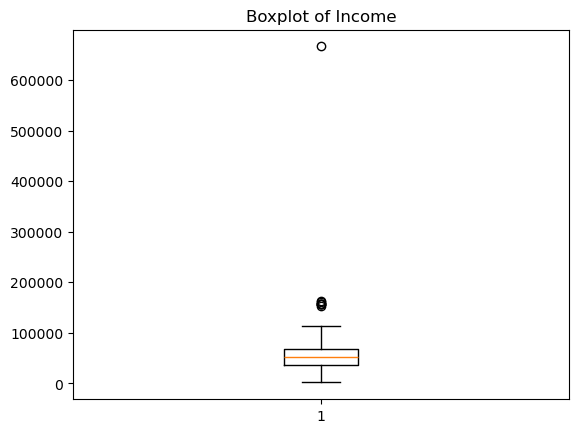

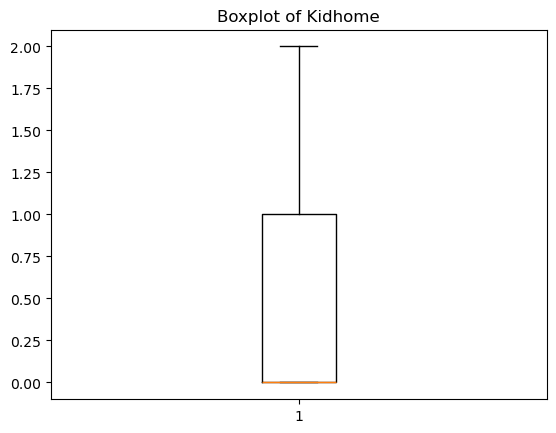

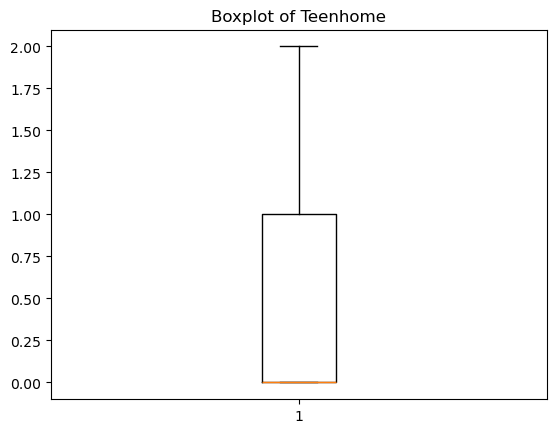

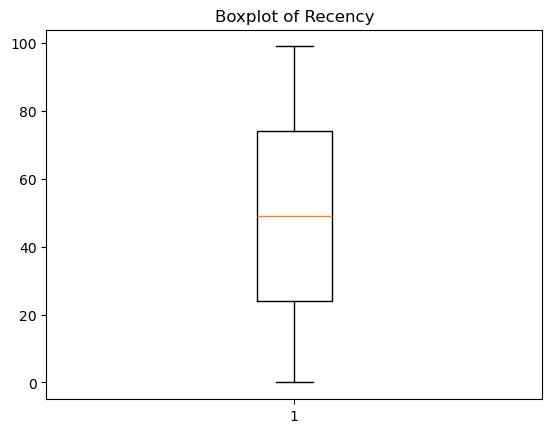

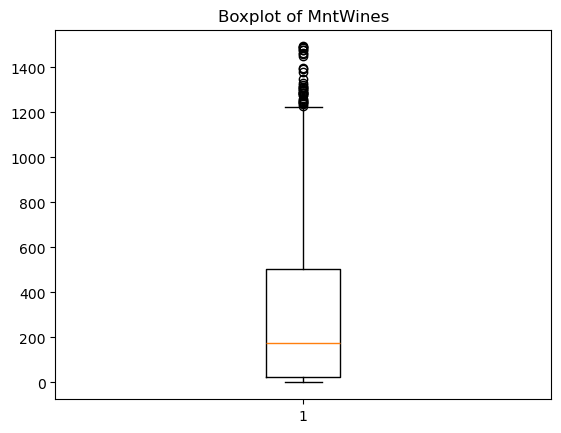

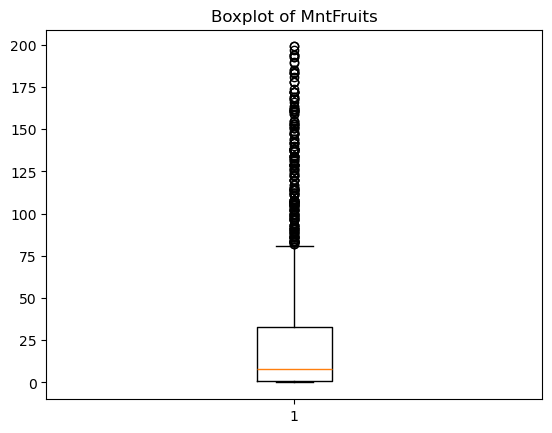

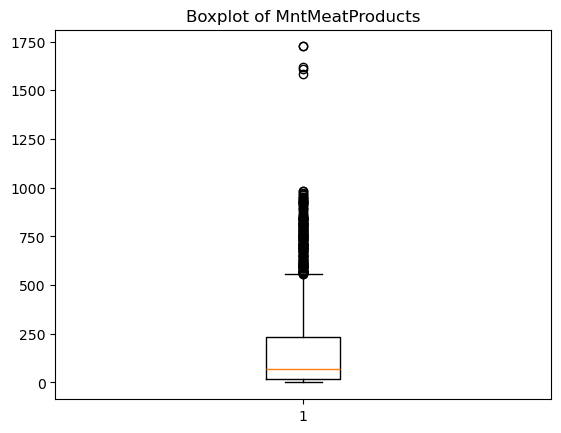

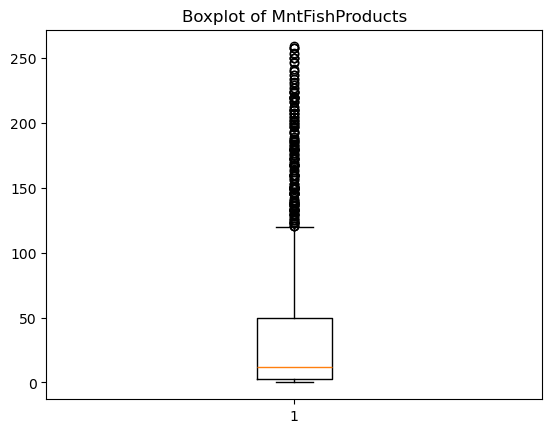

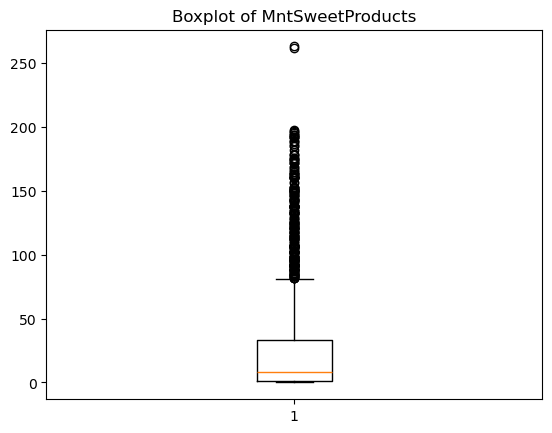

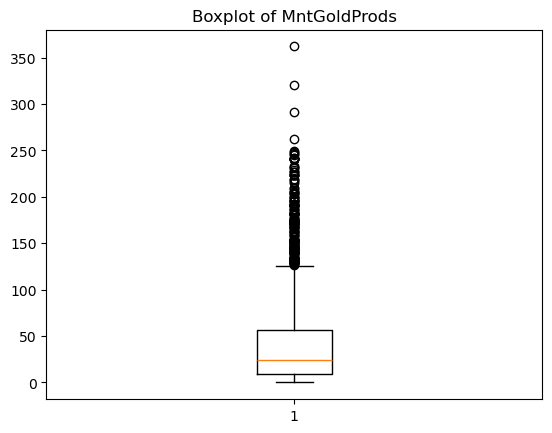

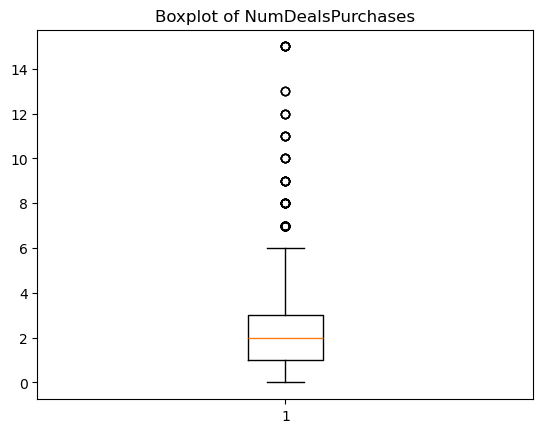

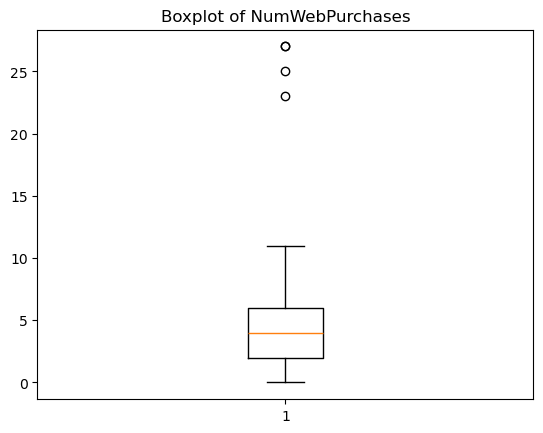

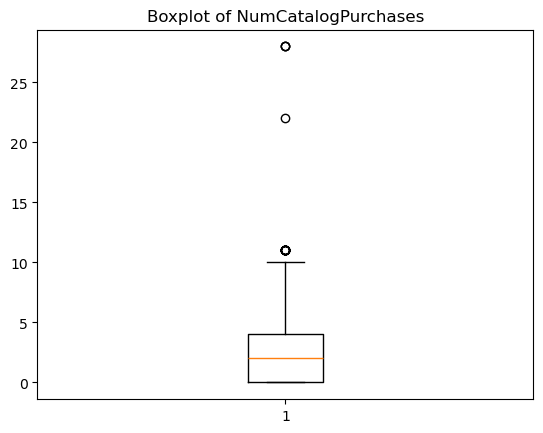

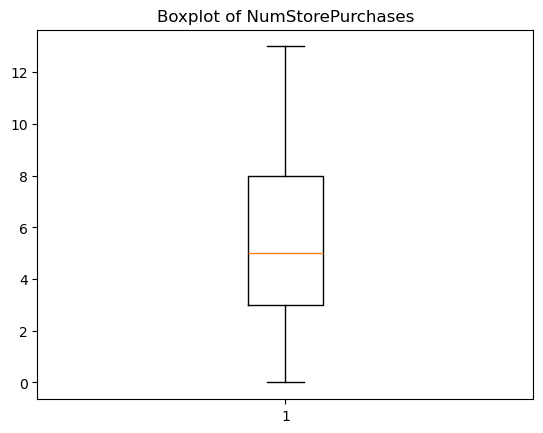

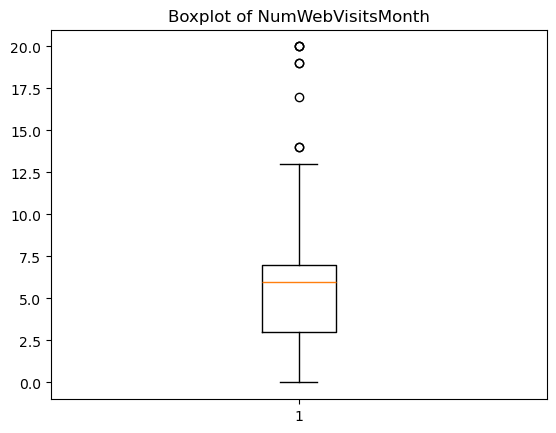

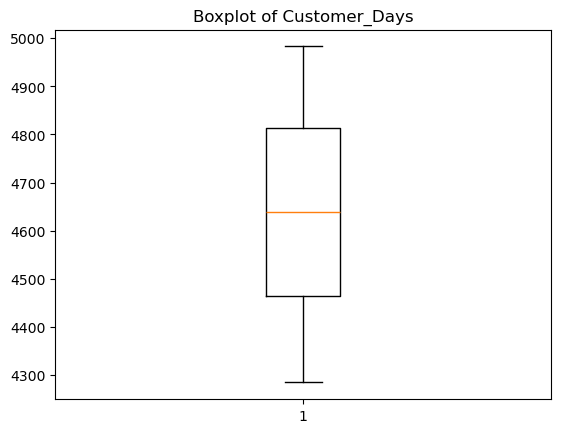

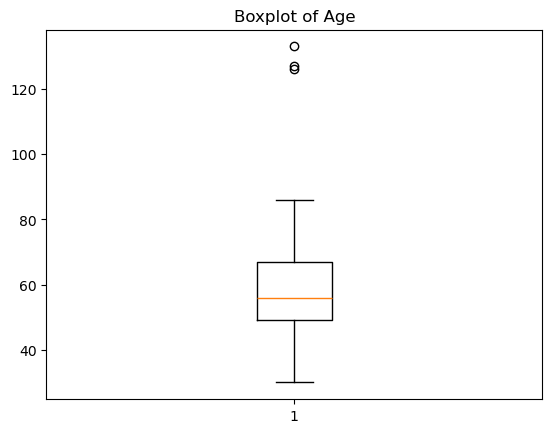

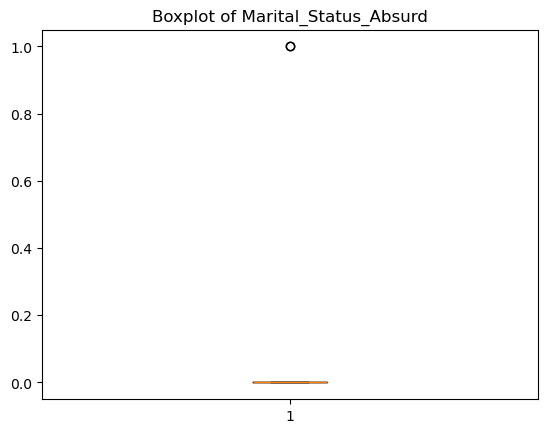

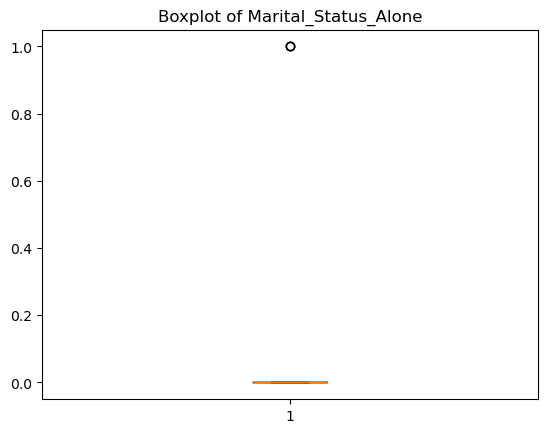

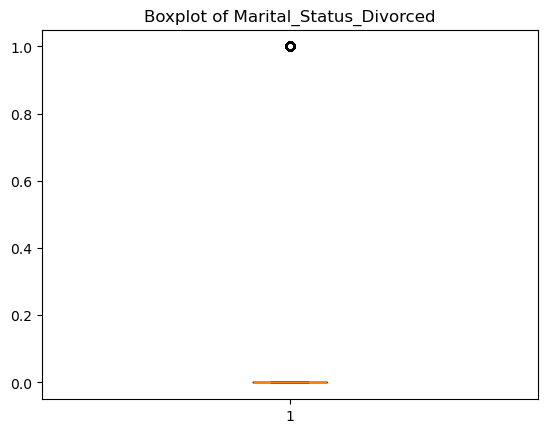

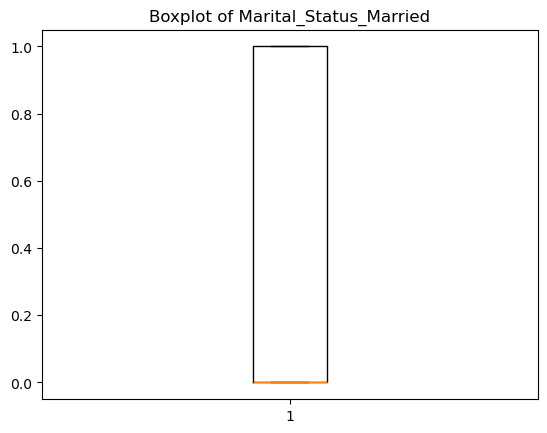

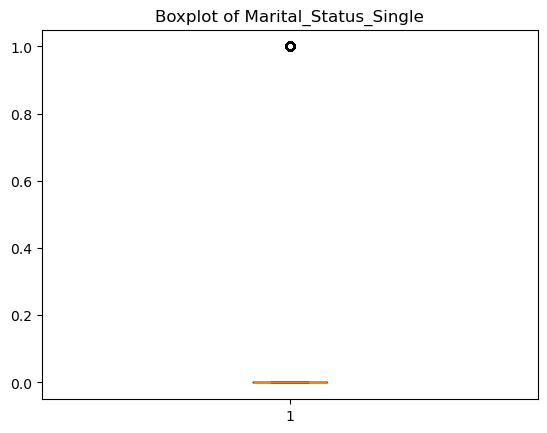

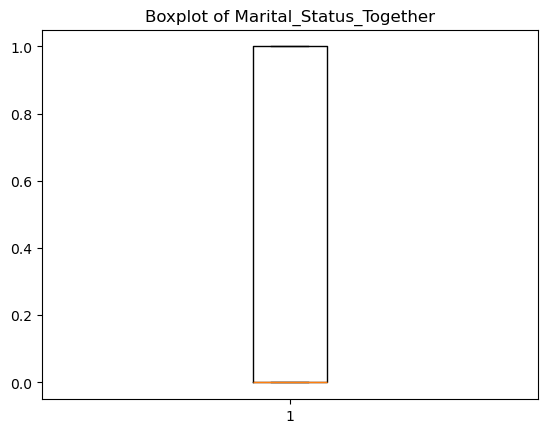

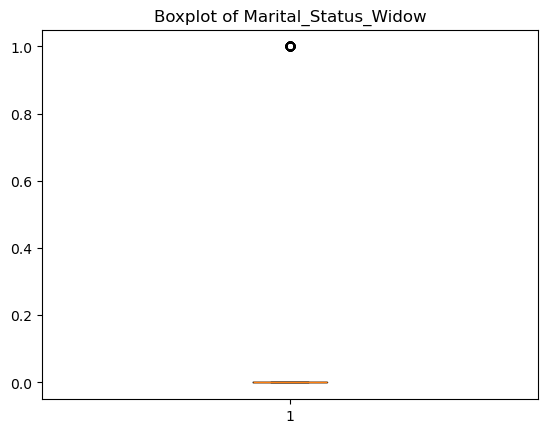

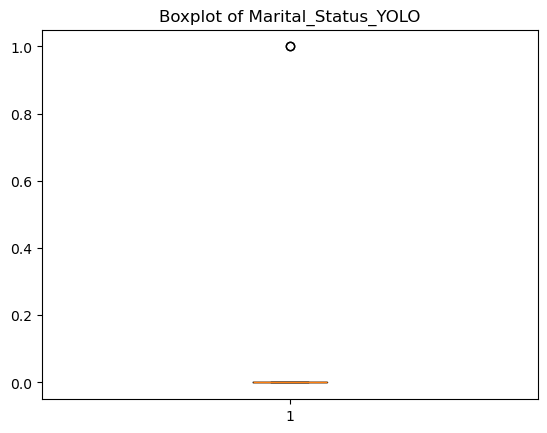

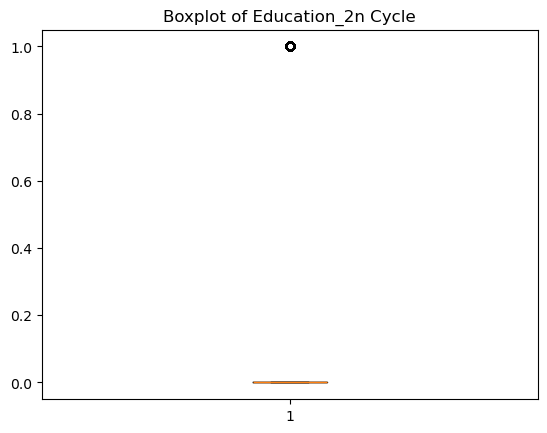

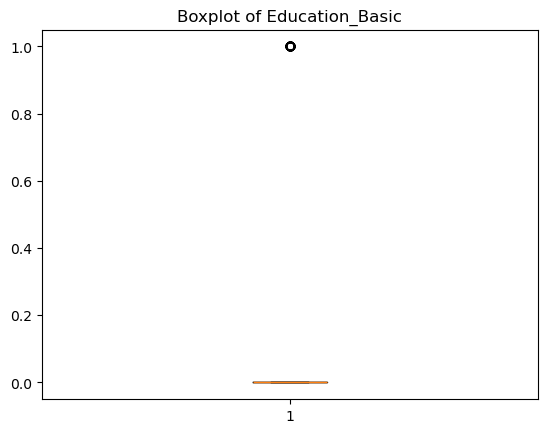

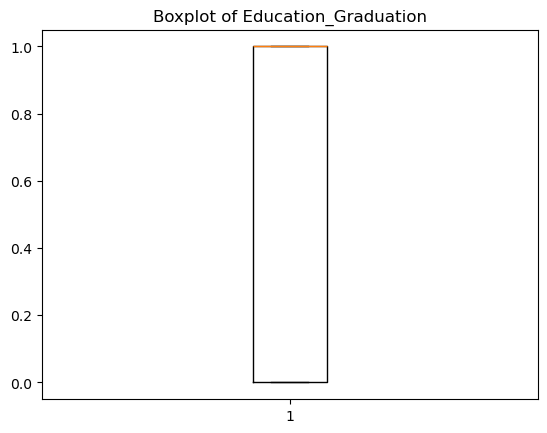

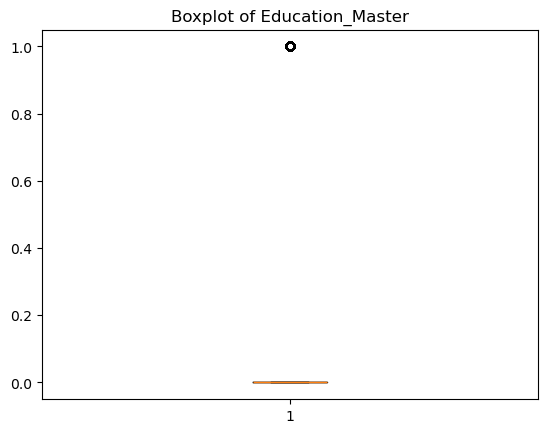

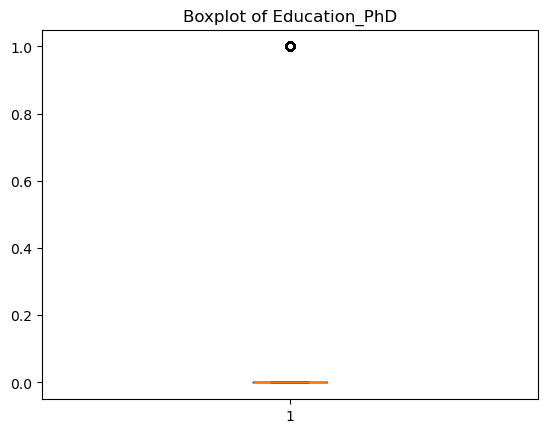

In [201]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [202]:
spending_cols = [
    'MntWines','MntFruits','MntMeatProducts',
    'MntFishProducts','MntSweetProducts','MntGoldProds']
for col in spending_cols:
    df[col] = np.log1p(df[col])

In [203]:
df['Income'] = np.log1p(df['Income'])

In [204]:
df['NumWebPurchases'] = np.log1p(df['NumWebPurchases'])
df = df[df['Age'] <= 100]

In [205]:
df['Age'].max()

86

In [206]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [207]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_scaled)

In [208]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.13251578218039944


In [209]:
for k in range(2, 10):
    kmeans = KMeans(n_clusters= k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, Score={score}")

K=2, Score=0.1883972267831195
K=3, Score=0.19003318045886583
K=4, Score=0.13251578218039944
K=5, Score=0.09974149247972612
K=6, Score=0.09828056417351273
K=7, Score=0.10270653355287822
K=8, Score=0.10892354069411823
K=9, Score=0.11021893737883226


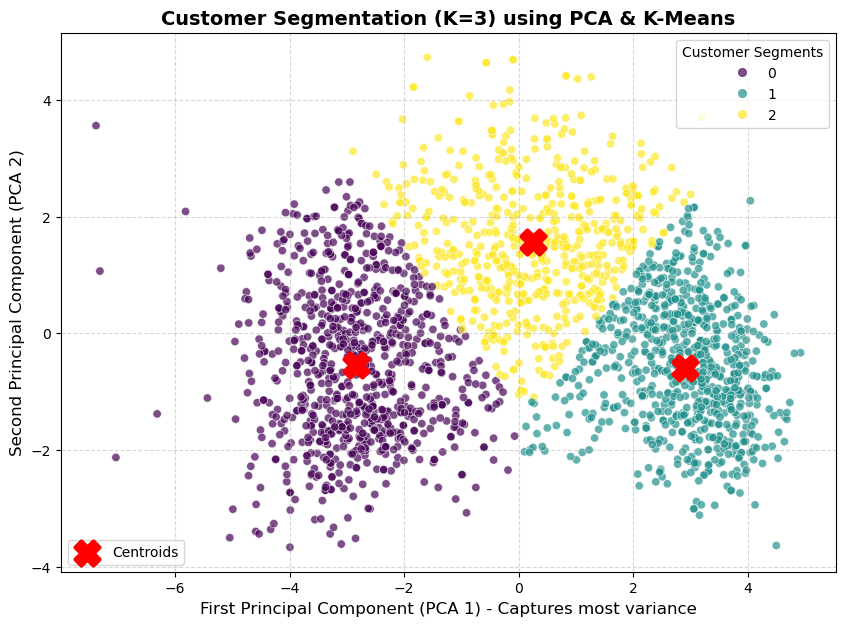

In [210]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=3, random_state=42, init='k-means++')
labels = kmeans.fit_predict(X_pca)

centroids = kmeans.cluster_centers_

plt.figure(figsize=(10, 7))

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', 
                      alpha=0.7, edgecolors='white', linewidths=0.5)

plt.scatter(centroids[:, 0], centroids[:, 1], 
            color='red', marker='X', s=300, linewidths=3, label='Centroids')

legend1 = plt.legend(*scatter.legend_elements(), title="Customer Segments", loc="upper right")
plt.gca().add_artist(legend1)
plt.legend(loc="lower left") 

plt.title("Customer Segmentation (K=3) using PCA & K-Means", fontsize=14, fontweight='bold')
plt.xlabel("First Principal Component (PCA 1) - Captures most variance", fontsize=12)
plt.ylabel("Second Principal Component (PCA 2)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()
